### Estudo da variabilidade das respostas dos modelos OpenSource SLR2

Vamos simular as variabilidade das respostas dos lhamas, olhando os resultados processados diversas vezes para cada modelo.

In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score
from together import Together
import numpy as np
import time
import os
from dotenv import load_dotenv, find_dotenv
from tqdm import tqdm
import matplotlib.pyplot as plt

In [2]:
### style de execução
tqdm.pandas()

### variaveis de ambiente e conexões

In [3]:
# Carrega as variáveis do arquivo .env
load_dotenv("/data/codigos/.env")

True

In [4]:
for key in os.environ.keys():
    print(f'{key}')

HOSTNAME
HOME
GPG_KEY
PYTHON_SHA256
PATH
LANG
SHELL
PYTHON_VERSION
PWD
VSCODE_CWD
VSCODE_NLS_CONFIG
VSCODE_HANDLES_SIGPIPE
VSCODE_ESM_ENTRYPOINT
VSCODE_HANDLES_UNCAUGHT_ERRORS
REMOTE_CONTAINERS_IPC
REMOTE_CONTAINERS_SOCKETS
SHLVL
_
REMOTE_CONTAINERS
BROWSER
ELECTRON_RUN_AS_NODE
VSCODE_IPC_HOOK_CLI
APPLICATION_INSIGHTS_NO_STATSBEAT
VSCODE_L10N_BUNDLE_LOCATION
PYDEVD_IPYTHON_COMPATIBLE_DEBUGGING
PYTHONUNBUFFERED
PYTHONIOENCODING
PYTHON_FROZEN_MODULES
PYDEVD_USE_FRAME_EVAL
TERM
CLICOLOR
FORCE_COLOR
CLICOLOR_FORCE
PAGER
GIT_PAGER
MPLBACKEND
KMP_DUPLICATE_LIB_OK
KMP_INIT_AT_FORK
OPENAI_API_KEY_GOV_ANALITICA
GOOGLE_API_KEY_LLMS_PROF_DANILO
ANTROPIC_API_KEY_LLMS
TOGETHER_API_KEY_LLMS
GOOGLE_CLOUD_PROJECT
GOOGLE_CLOUD_REGION


In [5]:
client = Together(api_key = os.getenv('TOGETHER_API_KEY_LLMS'))

# Together para usar os lhamas
-----

### Leitura dos arquivos

In [8]:
df_slr2 = pd.read_excel("/data/codigos/dados/titulo_resumo_palavras_slr2_v2.xlsx",engine='openpyxl')
df_slr2.head()

,ID,Title,resumo,keywords,sucesso_fracasso_resumo,sucesso_fracasso_palavras,segunda_coleta,obs,flag_pdfs,tentar_via_vpn
0,slr2_1,Redesigning the bartle test of gamer psycholog...,"According to the literature review, to impleme...","Bartle Test, Video Games, Gamification, Motiva...",sucesso,sucesso,não,não estruturado,sim,NaN
1,slr2_2,Towards adaptive gamification: A synthesis of ...,Adaptive gamification is an emerging and fast-...,"Adaptive gamification, structured literature r...",sucesso,sucesso,não,não estruturado,sim,NaN
2,slr2_3,Field guide to gamification: Game components a...,Although digital and analogue games differ in ...,"gamification, mechanical engineering, higher e...",sucesso,sucesso,não,não estruturado,sim,NaN
3,slr2_4,Gamification of eHealth interventions to incre...,Approximately one in five people in the United...,"eHealth, gamification, mental health, user eng...",sucesso,sucesso,não,não estruturado,sim,NaN
4,slr2_5,The relationship between gender and game dynam...,Despite relatively equal participation rate be...,"gender differences, competition, achievement, ...",sucesso,sucesso,não,não estruturado,sim,NaN


In [9]:
df_slr2 = df_slr2.replace({r'_x000D_|\n': ''}, regex=True)

In [10]:
df_slr2.head()

,ID,Title,resumo,keywords,sucesso_fracasso_resumo,sucesso_fracasso_palavras,segunda_coleta,obs,flag_pdfs,tentar_via_vpn
0,slr2_1,Redesigning the bartle test of gamer psycholog...,"According to the literature review, to impleme...","Bartle Test, Video Games, Gamification, Motiva...",sucesso,sucesso,não,não estruturado,sim,NaN
1,slr2_2,Towards adaptive gamification: A synthesis of ...,Adaptive gamification is an emerging and fast-...,"Adaptive gamification, structured literature r...",sucesso,sucesso,não,não estruturado,sim,NaN
2,slr2_3,Field guide to gamification: Game components a...,Although digital and analogue games differ in ...,"gamification, mechanical engineering, higher e...",sucesso,sucesso,não,não estruturado,sim,NaN
3,slr2_4,Gamification of eHealth interventions to incre...,Approximately one in five people in the United...,"eHealth, gamification, mental health, user eng...",sucesso,sucesso,não,não estruturado,sim,NaN
4,slr2_5,The relationship between gender and game dynam...,Despite relatively equal participation rate be...,"gender differences, competition, achievement, ...",sucesso,sucesso,não,não estruturado,sim,NaN


#### Limpeza dos casos em que não conseguimos extrair as informações


In [11]:
# Calcula a quantidade de valores por nível no campo "sucesso_fracasso"
sucesso_fracasso_counts = df_slr2['sucesso_fracasso_resumo'].value_counts()
print(sucesso_fracasso_counts)

sucesso_fracasso_resumo
sucesso     434
fracasso     14
Name: count, dtype: int64


In [12]:
# Calcula a quantidade de valores por nível no campo "sucesso_fracasso"
sucesso_fracasso_counts2 = df_slr2['sucesso_fracasso_palavras'].value_counts()
print(sucesso_fracasso_counts2)

sucesso_fracasso_palavras
sucesso     392
fracasso     56
Name: count, dtype: int64


In [13]:
# aqui precisamos, para reproduzir o artigo que ambos os campos tenho informação
df_slr2_clear = df_slr2.loc[((df_slr2['sucesso_fracasso_resumo'].isin(['sucesso']))&(df_slr2['sucesso_fracasso_palavras'].isin(['sucesso'])))].copy()
df_slr2_clear.shape

(392, 10)

In [14]:
print(df_slr2_clear["sucesso_fracasso_resumo"].value_counts())
print(df_slr2_clear["sucesso_fracasso_palavras"].value_counts())

sucesso_fracasso_resumo
sucesso    392
Name: count, dtype: int64
sucesso_fracasso_palavras
sucesso    392
Name: count, dtype: int64


In [15]:
print("Shape antes da limpeza: "+str(df_slr2.shape))
print("Shape depois da limpeza"+str(df_slr2_clear.shape))

Shape antes da limpeza: (448, 10)
Shape depois da limpeza(392, 10)


In [16]:
# Renomear as colunas do dataframe df_slr2_clear
df_slr2_clear.rename(columns={"Title": "title", "resumo": "abstract"}, inplace=True)
df_slr2_clear.head(2)

,ID,title,abstract,keywords,sucesso_fracasso_resumo,sucesso_fracasso_palavras,segunda_coleta,obs,flag_pdfs,tentar_via_vpn
0,slr2_1,Redesigning the bartle test of gamer psycholog...,"According to the literature review, to impleme...","Bartle Test, Video Games, Gamification, Motiva...",sucesso,sucesso,não,não estruturado,sim,NaN
1,slr2_2,Towards adaptive gamification: A synthesis of ...,Adaptive gamification is an emerging and fast-...,"Adaptive gamification, structured literature r...",sucesso,sucesso,não,não estruturado,sim,NaN


### Seleção usando o model_together

In [17]:
def process_selection_with_together(model_together, title, abstract, keywords,inclusion_criteria_question,client):
    """
    realiza a seleção dos artigos usando a escala likert, conforme o artigo original
    """
    
    # Contexto final para responder as perguntas
    system_message = {
        "role": "system", 
        "content": """Assume you are a software engineering researcher. 
        Conducting a systematic literature review (SLR). Consider the title, abstract and keywords of a primary study"""
    }

    # Prompt final com as perguntas

    # Prompt final com as perguntas, aprimorado para o último bloco
    user_message = { "role": "user",
                     "content": f"""Using a 1-7 Likert scale (1 - Strongly disagree, 2 - Disagree, 3 - Somewhat disagree, 
                    4 - Neither agree nor disagree, 5 - Somewhat agree, 6 - Agree, and 7 - Strongly agree) 
                    rate your agreement with the question (only number, not symbols or letters):  
                    {inclusion_criteria_question}. About the article: 
                    Title: {title}\n Abstract: {abstract}\n Keywords: {keywords} \n
                    Respond with only the number, with no other text or explanation."""
                    }

   
    # Criação da chamada para a API
    response = client.chat.completions.create(
        model="meta-llama/"+model_together,
        messages=[system_message, user_message],
        temperature=0,
        max_tokens=1,
        top_p=0.1
    )

    try:
        resposta = int(response.choices[0].message.content)
    except Exception as e:
        resposta = response.choices[0].message.content
        print("Erro ao processar:", e)
        print(str(response.choices[0].message.content))
        print(str(title))

    return resposta

In [18]:
model_together = "Llama-3.2-3B-Instruct-Turbo"
title1 = df_slr2_clear['title'].iloc[34]
abstract1 =  df_slr2_clear['abstract'].iloc[34]
keywords1 = df_slr2_clear['keywords'].iloc[34]
inclusion_criteria_question1 =  """The article discusses the relationship between game
 elements and user types."""

process_selection_with_together(model_together = model_together,
                          title = title1,
                          abstract = abstract1,
                          keywords=keywords1,
                          inclusion_criteria_question = inclusion_criteria_question1,
                          client=client)


4

In [19]:
def repeat_selection_with_together(df, model_together, inclusion_criteria_question, client,n_interactions,name_ic):
    """
    Repete o processo de seleção para todos os registros do dataframe
    """
    for i in range(n_interactions):
        print(i)
        coluna_aux = model_together+"_"+name_ic+"_"+str(i)
        temp_filename = f"/data/codigos/dados/resultados/temps/temp_slr2_{model_together}_{name_ic}_iter_{i}_v2.xlsx"
        df[coluna_aux] = df.progress_apply(lambda row: process_selection_with_together(model_together,
                                                                                    row['title'],
                                                                                    row['abstract'],
                                                                                    row['keywords'],
                                                                                    inclusion_criteria_question,
                                                                                    client), axis=1)
         # salvando para nao perder
        df.to_excel(temp_filename, index=False)
        time.sleep(60)  # pausa de 20 segundos entre as interações
    return df

#### Modelo: "meta-llama/Llama-3.2-3B-Instruct-Turbo"

In [20]:
df_gpt_4o  = df_slr2_clear.copy()
df_gpt_4o.head(2)

,ID,title,abstract,keywords,sucesso_fracasso_resumo,sucesso_fracasso_palavras,segunda_coleta,obs,flag_pdfs,tentar_via_vpn
0,slr2_1,Redesigning the bartle test of gamer psycholog...,"According to the literature review, to impleme...","Bartle Test, Video Games, Gamification, Motiva...",sucesso,sucesso,não,não estruturado,sim,NaN
1,slr2_2,Towards adaptive gamification: A synthesis of ...,Adaptive gamification is an emerging and fast-...,"Adaptive gamification, structured literature r...",sucesso,sucesso,não,não estruturado,sim,NaN


In [21]:
n_interactions = 5  # fixemos em 10 vezes devido ao custo

In [22]:
# repetir o mesmo processamento n vezes
model_gpt = "Llama-3.2-3B-Instruct-Turbo" # @param ["gpt-4-turbo-preview", "gpt-4", "gpt-3.5-turbo"]
inclusion_criteria_question = """It is a secondary study (Systematic Review, Mapping
 Study, Rapid Review, or Systematic Mapping)"""
name_ic = "IC1"
df_gpt_4o = repeat_selection_with_together(df = df_gpt_4o,
                                        model_together = model_gpt,
                                        inclusion_criteria_question = inclusion_criteria_question,
                                        client = client,
                                        n_interactions = n_interactions,
                                        name_ic = name_ic)

0


100%|██████████| 392/392 [02:40<00:00,  2.44it/s]


1


100%|██████████| 392/392 [02:20<00:00,  2.79it/s]


2


100%|██████████| 392/392 [02:06<00:00,  3.11it/s]


3


100%|██████████| 392/392 [01:54<00:00,  3.43it/s]


4


100%|██████████| 392/392 [02:07<00:00,  3.08it/s]


In [23]:
df_gpt_4o.head(2)

,ID,title,abstract,keywords,sucesso_fracasso_resumo,sucesso_fracasso_palavras,segunda_coleta,obs,flag_pdfs,tentar_via_vpn,Llama-3.2-3B-Instruct-Turbo_IC1_0,Llama-3.2-3B-Instruct-Turbo_IC1_1,Llama-3.2-3B-Instruct-Turbo_IC1_2,Llama-3.2-3B-Instruct-Turbo_IC1_3,Llama-3.2-3B-Instruct-Turbo_IC1_4
0,slr2_1,Redesigning the bartle test of gamer psycholog...,"According to the literature review, to impleme...","Bartle Test, Video Games, Gamification, Motiva...",sucesso,sucesso,não,não estruturado,sim,NaN,4,4,4,4,4
1,slr2_2,Towards adaptive gamification: A synthesis of ...,Adaptive gamification is an emerging and fast-...,"Adaptive gamification, structured literature r...",sucesso,sucesso,não,não estruturado,sim,NaN,4,4,4,4,4


In [24]:
# repetir o mesmo processamento n vezes
model_gpt = "Llama-3.2-3B-Instruct-Turbo" # @param ["gpt-4-turbo-preview", "gpt-4", "gpt-3.5-turbo"]
inclusion_criteria_question =""" It presents findings for converging Human-Computer
 Interaction and Artificial Intelligence"""
name_ic = "IC2"
df_gpt_4o = repeat_selection_with_together(df = df_gpt_4o,
                                        model_together = model_gpt,
                                        inclusion_criteria_question = inclusion_criteria_question,
                                        client = client,
                                        n_interactions = n_interactions,
                                        name_ic = name_ic)

0


100%|██████████| 392/392 [02:19<00:00,  2.80it/s]


1


100%|██████████| 392/392 [02:35<00:00,  2.52it/s]


2


100%|██████████| 392/392 [03:21<00:00,  1.94it/s]


3


100%|██████████| 392/392 [02:11<00:00,  2.99it/s]


4


100%|██████████| 392/392 [04:21<00:00,  1.50it/s]


In [25]:
df_gpt_4o.head()

,ID,title,abstract,keywords,sucesso_fracasso_resumo,sucesso_fracasso_palavras,segunda_coleta,obs,flag_pdfs,tentar_via_vpn,Llama-3.2-3B-Instruct-Turbo_IC1_0,Llama-3.2-3B-Instruct-Turbo_IC1_1,Llama-3.2-3B-Instruct-Turbo_IC1_2,Llama-3.2-3B-Instruct-Turbo_IC1_3,Llama-3.2-3B-Instruct-Turbo_IC1_4,Llama-3.2-3B-Instruct-Turbo_IC2_0,Llama-3.2-3B-Instruct-Turbo_IC2_1,Llama-3.2-3B-Instruct-Turbo_IC2_2,Llama-3.2-3B-Instruct-Turbo_IC2_3,Llama-3.2-3B-Instruct-Turbo_IC2_4
0,slr2_1,Redesigning the bartle test of gamer psycholog...,"According to the literature review, to impleme...","Bartle Test, Video Games, Gamification, Motiva...",sucesso,sucesso,não,não estruturado,sim,NaN,4,4,4,4,4,6,6,6,6,6
1,slr2_2,Towards adaptive gamification: A synthesis of ...,Adaptive gamification is an emerging and fast-...,"Adaptive gamification, structured literature r...",sucesso,sucesso,não,não estruturado,sim,NaN,4,4,4,4,4,6,6,6,6,6
2,slr2_3,Field guide to gamification: Game components a...,Although digital and analogue games differ in ...,"gamification, mechanical engineering, higher e...",sucesso,sucesso,não,não estruturado,sim,NaN,4,4,4,4,4,4,4,4,4,4
3,slr2_4,Gamification of eHealth interventions to incre...,Approximately one in five people in the United...,"eHealth, gamification, mental health, user eng...",sucesso,sucesso,não,não estruturado,sim,NaN,4,4,4,4,4,6,6,6,6,6
4,slr2_5,The relationship between gender and game dynam...,Despite relatively equal participation rate be...,"gender differences, competition, achievement, ...",sucesso,sucesso,não,não estruturado,sim,NaN,4,4,4,4,4,4,4,4,4,4


#### Modelo "meta-llama/Llama-3.3-70B-Instruct-Turbo-Free"

In [28]:
df_gpt_3_5  = df_slr2_clear.copy()
df_gpt_3_5.head(2)

,ID,title,abstract,keywords,sucesso_fracasso_resumo,sucesso_fracasso_palavras,segunda_coleta,obs,flag_pdfs,tentar_via_vpn
0,slr2_1,Redesigning the bartle test of gamer psycholog...,"According to the literature review, to impleme...","Bartle Test, Video Games, Gamification, Motiva...",sucesso,sucesso,não,não estruturado,sim,NaN
1,slr2_2,Towards adaptive gamification: A synthesis of ...,Adaptive gamification is an emerging and fast-...,"Adaptive gamification, structured literature r...",sucesso,sucesso,não,não estruturado,sim,NaN


In [29]:
n_interactions = 5  # fixemos em 10 vezes devido ao custo

In [30]:
# repetir o mesmo processamento n vezes
model_gpt = "Llama-3.3-70B-Instruct-Turbo-Free" # @param ["gpt-4-turbo-preview", "gpt-4", "gpt-3.5-turbo"]
inclusion_criteria_question = """TIt is a secondary study (Systematic Review, Mapping
 Study, Rapid Review, or Systematic Mapping)"""
name_ic = "IC1"
df_gpt_3_5 = repeat_selection_with_together(df = df_gpt_3_5,
                                        model_together = model_gpt,
                                        inclusion_criteria_question = inclusion_criteria_question,
                                        client = client,
                                        n_interactions = n_interactions,
                                        name_ic = name_ic)

0


100%|██████████| 392/392 [1:23:55<00:00, 12.85s/it]


1


100%|██████████| 392/392 [1:01:55<00:00,  9.48s/it]


2


100%|██████████| 392/392 [1:21:10<00:00, 12.42s/it]


3


100%|██████████| 392/392 [59:07<00:00,  9.05s/it]  


4


100%|██████████| 392/392 [1:18:30<00:00, 12.02s/it]


In [31]:
# repetir o mesmo processamento n vezes
model_gpt = "Llama-3.3-70B-Instruct-Turbo-Free" # @param ["gpt-4-turbo-preview", "gpt-4", "gpt-3.5-turbo"]
inclusion_criteria_question =""" It presents findings for converging Human-Computer
 Interaction and Artificial Intelligence"""
name_ic = "IC2"
df_gpt_3_5 = repeat_selection_with_together(df = df_gpt_3_5,
                                        model_together = model_gpt,
                                        inclusion_criteria_question = inclusion_criteria_question,
                                        client = client,
                                        n_interactions = n_interactions,
                                        name_ic = name_ic)

0


100%|██████████| 392/392 [1:20:08<00:00, 12.27s/it] 


1


100%|██████████| 392/392 [1:16:37<00:00, 11.73s/it]


2


100%|██████████| 392/392 [57:45<00:00,  8.84s/it] 


3


100%|██████████| 392/392 [1:23:54<00:00, 12.84s/it]


4


100%|██████████| 392/392 [1:02:05<00:00,  9.50s/it]


### Modelo "meta-llama/Llama-4-Scout-17B-16E-Instruct"

In [40]:
df_gpt_4_1  = df_slr2_clear.copy()
df_gpt_4_1.head(2)

,ID,title,abstract,keywords,sucesso_fracasso_resumo,sucesso_fracasso_palavras,segunda_coleta,obs,flag_pdfs,tentar_via_vpn
0,slr2_1,Redesigning the bartle test of gamer psycholog...,"According to the literature review, to impleme...","Bartle Test, Video Games, Gamification, Motiva...",sucesso,sucesso,não,não estruturado,sim,NaN
1,slr2_2,Towards adaptive gamification: A synthesis of ...,Adaptive gamification is an emerging and fast-...,"Adaptive gamification, structured literature r...",sucesso,sucesso,não,não estruturado,sim,NaN


In [41]:
df_gpt_4_1.iloc[34, ]

ID                                                                     slr2_35
title                        A personalized gamification method for increas...
abstract                     Reward-based gamification which increases user...
keywords                     Personalized gamification, Social network, Use...
sucesso_fracasso_resumo                                                sucesso
sucesso_fracasso_palavras                                              sucesso
segunda_coleta                                                             não
obs                                                            não estruturado
flag_pdfs                                                                  sim
tentar_via_vpn                                                             NaN
Name: 34, dtype: object

In [42]:
n_interactions = 5  # fixemos em 10 vezes devido ao custo

In [43]:
# repetir o mesmo processamento n vezes
model_gpt = "Llama-4-Scout-17B-16E-Instruct" # @param ["gpt-4-turbo-preview", "gpt-4", "gpt-3.5-turbo"]
inclusion_criteria_question = """It is a secondary study (Systematic Review, Mapping
 Study, Rapid Review, or Systematic Mapping)"""
name_ic = "IC1"
df_gpt_4_1 = repeat_selection_with_together(df = df_gpt_4_1,
                                        model_together = model_gpt,
                                        inclusion_criteria_question = inclusion_criteria_question,
                                        client = client,
                                        n_interactions = n_interactions,
                                        name_ic = name_ic)

0


100%|██████████| 392/392 [01:57<00:00,  3.33it/s]


1


100%|██████████| 392/392 [02:41<00:00,  2.43it/s]


2


100%|██████████| 392/392 [01:54<00:00,  3.41it/s]


3


100%|██████████| 392/392 [02:02<00:00,  3.20it/s]


4


100%|██████████| 392/392 [01:55<00:00,  3.38it/s]


In [45]:
# repetir o mesmo processamento n vezes
model_gpt = "Llama-4-Scout-17B-16E-Instruct" # @param ["gpt-4-turbo-preview", "gpt-4", "gpt-3.5-turbo"]
inclusion_criteria_question =""" It presents findings for converging Human-Computer
 Interaction and Artificial Intelligence"""
name_ic = "IC2"
df_gpt_4_1 = repeat_selection_with_together(df = df_gpt_4_1,
                                        model_together = model_gpt,
                                        inclusion_criteria_question = inclusion_criteria_question,
                                        client = client,
                                        n_interactions = n_interactions,
                                        name_ic = name_ic)

0


100%|██████████| 392/392 [01:55<00:00,  3.40it/s]


1


100%|██████████| 392/392 [01:51<00:00,  3.52it/s]


2


100%|██████████| 392/392 [02:03<00:00,  3.17it/s]


3


100%|██████████| 392/392 [02:00<00:00,  3.26it/s]


4


100%|██████████| 392/392 [01:52<00:00,  3.50it/s]


### Gravação

#### Llama-3.3-70B-Instruct-Turbo-Free

In [32]:
df_gpt_3_5.head(2)

,ID,title,abstract,keywords,sucesso_fracasso_resumo,sucesso_fracasso_palavras,segunda_coleta,obs,flag_pdfs,tentar_via_vpn,Llama-3.3-70B-Instruct-Turbo-Free_IC1_0,Llama-3.3-70B-Instruct-Turbo-Free_IC1_1,Llama-3.3-70B-Instruct-Turbo-Free_IC1_2,Llama-3.3-70B-Instruct-Turbo-Free_IC1_3,Llama-3.3-70B-Instruct-Turbo-Free_IC1_4,Llama-3.3-70B-Instruct-Turbo-Free_IC2_0,Llama-3.3-70B-Instruct-Turbo-Free_IC2_1,Llama-3.3-70B-Instruct-Turbo-Free_IC2_2,Llama-3.3-70B-Instruct-Turbo-Free_IC2_3,Llama-3.3-70B-Instruct-Turbo-Free_IC2_4
0,slr2_1,Redesigning the bartle test of gamer psycholog...,"According to the literature review, to impleme...","Bartle Test, Video Games, Gamification, Motiva...",sucesso,sucesso,não,não estruturado,sim,NaN,1,1,1,1,1,2,2,2,2,2
1,slr2_2,Towards adaptive gamification: A synthesis of ...,Adaptive gamification is an emerging and fast-...,"Adaptive gamification, structured literature r...",sucesso,sucesso,não,não estruturado,sim,NaN,7,7,7,7,7,2,2,2,2,2


In [33]:
# grava os resultados
df_gpt_3_5.to_excel("/data/codigos/dados/resultados/reproducao_resultados_Llama-3.3-70B-Instruct-Turbo-Free_slr2_v2.xlsx", index=False)
df_gpt_3_5.to_csv("/data/codigos/dados/resultados/reproducao_resultados_Llama-3.3-70B-Instruct-Turbo-Free_slr2_v2.csv", encoding='utf-8', index=False)

#### Llama-3.2-3B-Instruct-Turbo"

In [26]:
df_gpt_4o.head(2)

,ID,title,abstract,keywords,sucesso_fracasso_resumo,sucesso_fracasso_palavras,segunda_coleta,obs,flag_pdfs,tentar_via_vpn,Llama-3.2-3B-Instruct-Turbo_IC1_0,Llama-3.2-3B-Instruct-Turbo_IC1_1,Llama-3.2-3B-Instruct-Turbo_IC1_2,Llama-3.2-3B-Instruct-Turbo_IC1_3,Llama-3.2-3B-Instruct-Turbo_IC1_4,Llama-3.2-3B-Instruct-Turbo_IC2_0,Llama-3.2-3B-Instruct-Turbo_IC2_1,Llama-3.2-3B-Instruct-Turbo_IC2_2,Llama-3.2-3B-Instruct-Turbo_IC2_3,Llama-3.2-3B-Instruct-Turbo_IC2_4
0,slr2_1,Redesigning the bartle test of gamer psycholog...,"According to the literature review, to impleme...","Bartle Test, Video Games, Gamification, Motiva...",sucesso,sucesso,não,não estruturado,sim,NaN,4,4,4,4,4,6,6,6,6,6
1,slr2_2,Towards adaptive gamification: A synthesis of ...,Adaptive gamification is an emerging and fast-...,"Adaptive gamification, structured literature r...",sucesso,sucesso,não,não estruturado,sim,NaN,4,4,4,4,4,6,6,6,6,6


In [27]:
# grava os resultados
df_gpt_4o.to_excel("/data/codigos/dados/resultados/reproducao_resultados_Llama-3.2-3B-Instruct-Turbo_slr2_v2.xlsx", index=False)
df_gpt_4o.to_csv("/data/codigos/dados/resultados/reproducao_resultados_Llama-3.2-3B-Instruct-Turbo _slr2_v2.csv", encoding='utf-8', index=False)

#### Llama-4-Scout-17B-16E-Instruct

In [46]:
df_gpt_4_1.head(2)

,ID,title,abstract,keywords,sucesso_fracasso_resumo,sucesso_fracasso_palavras,segunda_coleta,obs,flag_pdfs,tentar_via_vpn,Llama-4-Scout-17B-16E-Instruct_IC1_0,Llama-4-Scout-17B-16E-Instruct_IC1_1,Llama-4-Scout-17B-16E-Instruct_IC1_2,Llama-4-Scout-17B-16E-Instruct_IC1_3,Llama-4-Scout-17B-16E-Instruct_IC1_4,Llama-4-Scout-17B-16E-Instruct_IC2_0,Llama-4-Scout-17B-16E-Instruct_IC2_1,Llama-4-Scout-17B-16E-Instruct_IC2_2,Llama-4-Scout-17B-16E-Instruct_IC2_3,Llama-4-Scout-17B-16E-Instruct_IC2_4
0,slr2_1,Redesigning the bartle test of gamer psycholog...,"According to the literature review, to impleme...","Bartle Test, Video Games, Gamification, Motiva...",sucesso,sucesso,não,não estruturado,sim,NaN,2,2,2,2,2,2,2,2,2,2
1,slr2_2,Towards adaptive gamification: A synthesis of ...,Adaptive gamification is an emerging and fast-...,"Adaptive gamification, structured literature r...",sucesso,sucesso,não,não estruturado,sim,NaN,7,7,7,7,7,5,5,5,5,5


In [47]:
# grava os resultados
df_gpt_4_1.to_excel("/data/codigos/dados/resultados/reproducao_resultados_Llama-4-Scout-17B-16E-Instruct_slr2_v2.xlsx", index=False)
df_gpt_4_1.to_csv("/data/codigos/dados/resultados/reproducao_resultados_Llama-4-Scout-17B-16E-Instruct_slr2_v2.csv", encoding='utf-8', index=False)

## Analise dos resultados

### Leitura dos resultados processados

In [48]:
df_gpt3 = pd.read_csv("/data/codigos/dados/resultados/reproducao_resultados_Llama-3.3-70B-Instruct-Turbo-Free_slr2_v2.csv",encoding='utf-8')
df_gpt3.head(2)

,ID,title,abstract,keywords,sucesso_fracasso_resumo,sucesso_fracasso_palavras,segunda_coleta,obs,flag_pdfs,tentar_via_vpn,Llama-3.3-70B-Instruct-Turbo-Free_IC1_0,Llama-3.3-70B-Instruct-Turbo-Free_IC1_1,Llama-3.3-70B-Instruct-Turbo-Free_IC1_2,Llama-3.3-70B-Instruct-Turbo-Free_IC1_3,Llama-3.3-70B-Instruct-Turbo-Free_IC1_4,Llama-3.3-70B-Instruct-Turbo-Free_IC2_0,Llama-3.3-70B-Instruct-Turbo-Free_IC2_1,Llama-3.3-70B-Instruct-Turbo-Free_IC2_2,Llama-3.3-70B-Instruct-Turbo-Free_IC2_3,Llama-3.3-70B-Instruct-Turbo-Free_IC2_4
0,slr2_1,Redesigning the bartle test of gamer psycholog...,"According to the literature review, to impleme...","Bartle Test, Video Games, Gamification, Motiva...",sucesso,sucesso,não,não estruturado,sim,NaN,1,1,1,1,1,2,2,2,2,2
1,slr2_2,Towards adaptive gamification: A synthesis of ...,Adaptive gamification is an emerging and fast-...,"Adaptive gamification, structured literature r...",sucesso,sucesso,não,não estruturado,sim,NaN,7,7,7,7,7,2,2,2,2,2


In [49]:
df_gpt4 = pd.read_csv("/data/codigos/dados/resultados/reproducao_resultados_Llama-3.2-3B-Instruct-Turbo _slr2_v2.csv",encoding='utf-8')
df_gpt4.head(2)

,ID,title,abstract,keywords,sucesso_fracasso_resumo,sucesso_fracasso_palavras,segunda_coleta,obs,flag_pdfs,tentar_via_vpn,Llama-3.2-3B-Instruct-Turbo_IC1_0,Llama-3.2-3B-Instruct-Turbo_IC1_1,Llama-3.2-3B-Instruct-Turbo_IC1_2,Llama-3.2-3B-Instruct-Turbo_IC1_3,Llama-3.2-3B-Instruct-Turbo_IC1_4,Llama-3.2-3B-Instruct-Turbo_IC2_0,Llama-3.2-3B-Instruct-Turbo_IC2_1,Llama-3.2-3B-Instruct-Turbo_IC2_2,Llama-3.2-3B-Instruct-Turbo_IC2_3,Llama-3.2-3B-Instruct-Turbo_IC2_4
0,slr2_1,Redesigning the bartle test of gamer psycholog...,"According to the literature review, to impleme...","Bartle Test, Video Games, Gamification, Motiva...",sucesso,sucesso,não,não estruturado,sim,NaN,4,4,4,4,4,6,6,6,6,6
1,slr2_2,Towards adaptive gamification: A synthesis of ...,Adaptive gamification is an emerging and fast-...,"Adaptive gamification, structured literature r...",sucesso,sucesso,não,não estruturado,sim,NaN,4,4,4,4,4,6,6,6,6,6


In [50]:
df_gpt41 = pd.read_csv("/data/codigos/dados/resultados/reproducao_resultados_Llama-4-Scout-17B-16E-Instruct_slr2_v2.csv",encoding='utf-8')
df_gpt41.head(2)

,ID,title,abstract,keywords,sucesso_fracasso_resumo,sucesso_fracasso_palavras,segunda_coleta,obs,flag_pdfs,tentar_via_vpn,Llama-4-Scout-17B-16E-Instruct_IC1_0,Llama-4-Scout-17B-16E-Instruct_IC1_1,Llama-4-Scout-17B-16E-Instruct_IC1_2,Llama-4-Scout-17B-16E-Instruct_IC1_3,Llama-4-Scout-17B-16E-Instruct_IC1_4,Llama-4-Scout-17B-16E-Instruct_IC2_0,Llama-4-Scout-17B-16E-Instruct_IC2_1,Llama-4-Scout-17B-16E-Instruct_IC2_2,Llama-4-Scout-17B-16E-Instruct_IC2_3,Llama-4-Scout-17B-16E-Instruct_IC2_4
0,slr2_1,Redesigning the bartle test of gamer psycholog...,"According to the literature review, to impleme...","Bartle Test, Video Games, Gamification, Motiva...",sucesso,sucesso,não,não estruturado,sim,NaN,2,2,2,2,2,2,2,2,2,2
1,slr2_2,Towards adaptive gamification: A synthesis of ...,Adaptive gamification is an emerging and fast-...,"Adaptive gamification, structured literature r...",sucesso,sucesso,não,não estruturado,sim,NaN,7,7,7,7,7,5,5,5,5,5


In [51]:
# vamos trazer os dados disponibilizados pelos autores para comparação de performance
df_slr2_autores = pd.read_excel("/data/codigos/dados/slr2-results-keys.xlsx",engine='openpyxl')
df_slr2_autores.head()

,ID,Title,IC1,IC2,Benchmark,Execution time (s),Total Tokens
0,slr2_1,Redesigning the bartle test of gamer psycholog...,6,6,E,"1,7697742920136",777
1,slr2_2,Towards adaptive gamification: A synthesis of ...,5,5,I,"1,26788704199134",889
2,slr2_3,Field guide to gamification: Game components a...,7,7,I,"1,3752188339713",1233
3,slr2_4,Gamification of eHealth interventions to incre...,1,2,I,"1,54043745799572",1047
4,slr2_5,The relationship between gender and game dynam...,6,6,I,1.338598,1175


In [52]:
df_gpt3 = pd.merge(left=df_gpt3, right=df_slr2_autores[["ID","IC1","IC2","Benchmark"]],
                          left_on='ID', right_on='ID',how='left')
df_gpt3.shape


(392, 23)

In [53]:
df_gpt4 = pd.merge(left=df_gpt4, right=df_slr2_autores[["ID","IC1","IC2","Benchmark"]],
                          left_on='ID', right_on='ID',how='left')
df_gpt4.shape

(392, 23)

In [54]:
df_gpt41 = pd.merge(left=df_gpt41, right=df_slr2_autores[["ID","IC1","IC2","Benchmark"]],
                          left_on='ID', right_on='ID',how='left')
df_gpt41.shape

(392, 23)

In [55]:
print("df_gpt3: "+str(df_gpt3.shape))
print("df_gpt4: "+str(df_gpt4.shape))
print("df_gpt41: "+str(df_gpt41.shape))
print("df_slr2_autores: "+str(df_slr2_autores.shape))


df_gpt3: (392, 23)
df_gpt4: (392, 23)
df_gpt41: (392, 23)
df_slr2_autores: (448, 7)


### Geração dos resultados das llms e padronizacao dos campos

In [56]:
# criando a regra do corte em 5
def convert_benchmark(df,col1):
    df["result_bench"] = np.where(df[col1].str.lower()=="i",1,0)
    return df

In [57]:
df_gpt3 = convert_benchmark(df_gpt3,"Benchmark")

In [58]:
df_gpt4 = convert_benchmark(df_gpt4,"Benchmark")

In [59]:
df_gpt41 = convert_benchmark(df_gpt41,"Benchmark")

In [60]:
def create_result_llm_classic(df,col1,col2,limit1,limit2,col_name):
    """
    Create flag with result for llms
    """
    df["aux_ic1"] = np.where(df[col1]>=limit1,1,0)
    df["aux_ic2"] = np.where(df[col2]>=limit2,1,0)
    df[col_name] = np.where(((df["aux_ic1"]==1) & (df["aux_ic2"]==1)),1,0)
    return df.drop(columns=["aux_ic1","aux_ic2"])

In [61]:
df_gpt3.head(1)

,ID,title,abstract,keywords,sucesso_fracasso_resumo,sucesso_fracasso_palavras,segunda_coleta,obs,flag_pdfs,tentar_via_vpn,...,Llama-3.3-70B-Instruct-Turbo-Free_IC1_4,Llama-3.3-70B-Instruct-Turbo-Free_IC2_0,Llama-3.3-70B-Instruct-Turbo-Free_IC2_1,Llama-3.3-70B-Instruct-Turbo-Free_IC2_2,Llama-3.3-70B-Instruct-Turbo-Free_IC2_3,Llama-3.3-70B-Instruct-Turbo-Free_IC2_4,IC1,IC2,Benchmark,result_bench
0,slr2_1,Redesigning the bartle test of gamer psycholog...,"According to the literature review, to impleme...","Bartle Test, Video Games, Gamification, Motiva...",sucesso,sucesso,não,não estruturado,sim,NaN,...,1,2,2,2,2,2,6,6,E,0


In [62]:
# Cria a resposta final para cada iteração
def calculate_select_result_llm(n_interactions, model_gpt, df):
    name_ic1 = "IC1"
    name_ic2 = "IC2"
    for i in range(n_interactions):
        coluna_aux1 = model_gpt+"_"+name_ic1+"_"+str(i)
        coluna_aux2 = model_gpt+"_"+name_ic2+"_"+str(i)
        col_name = model_gpt+"_"+str(i)
        df = create_result_llm_classic(df=df,
                                        col1=coluna_aux1,
                                        col2=coluna_aux2,
                                        limit1=5,
                                        limit2=5,
                                        col_name=col_name)
    return df

In [63]:
n_interactions = 5
model_gpt = "Llama-3.3-70B-Instruct-Turbo-Free"
df_gpt3 = calculate_select_result_llm(n_interactions=n_interactions, model_gpt=model_gpt, df=df_gpt3)

In [64]:
df_gpt3.head(2)

,ID,title,abstract,keywords,sucesso_fracasso_resumo,sucesso_fracasso_palavras,segunda_coleta,obs,flag_pdfs,tentar_via_vpn,...,Llama-3.3-70B-Instruct-Turbo-Free_IC2_4,IC1,IC2,Benchmark,result_bench,Llama-3.3-70B-Instruct-Turbo-Free_0,Llama-3.3-70B-Instruct-Turbo-Free_1,Llama-3.3-70B-Instruct-Turbo-Free_2,Llama-3.3-70B-Instruct-Turbo-Free_3,Llama-3.3-70B-Instruct-Turbo-Free_4
0,slr2_1,Redesigning the bartle test of gamer psycholog...,"According to the literature review, to impleme...","Bartle Test, Video Games, Gamification, Motiva...",sucesso,sucesso,não,não estruturado,sim,NaN,...,2,6,6,E,0,0,0,0,0,0
1,slr2_2,Towards adaptive gamification: A synthesis of ...,Adaptive gamification is an emerging and fast-...,"Adaptive gamification, structured literature r...",sucesso,sucesso,não,não estruturado,sim,NaN,...,2,5,5,I,1,0,0,0,0,0


In [65]:
n_interactions = 5
model_gpt = "Llama-3.2-3B-Instruct-Turbo"
df_gpt4 = calculate_select_result_llm(n_interactions=n_interactions, model_gpt=model_gpt, df=df_gpt4)

In [66]:
n_interactions = 5
model_gpt = "Llama-4-Scout-17B-16E-Instruct"
df_gpt41 = calculate_select_result_llm(n_interactions=n_interactions, model_gpt=model_gpt, df=df_gpt41)

### Analises de performance

In [67]:
def calculate_accuracy(n_interactions, model_gpt, df, col_benchmark):
    """
    Calcula a acurácia para cada iteração e armazena os resultados em um dataframe.
    
    Parâmetros:
    n_interactions (int): Número de interações.
    model_gpt (str): Nome do modelo GPT.
    df (pd.DataFrame): DataFrame contendo os dados.
    col_benchmark (str): Nome da coluna de benchmark.
    
    Retorna:
    pd.DataFrame: DataFrame com as colunas 'Model_Iteration' e 'Accuracy'.
    """
    accuracy_results = []

    for i in range(n_interactions):
        col_name = model_gpt + "_" + str(i)
        accuracy = accuracy_score(df[col_benchmark], df[col_name])
        accuracy_results.append({'Model_Iteration': col_name, 'Accuracy': accuracy})

    return pd.DataFrame(accuracy_results)


In [68]:
n_interactions = 5
model_gpt = "Llama-3.3-70B-Instruct-Turbo-Free"
df_result_gpt3 = calculate_accuracy(n_interactions=n_interactions,
                                    model_gpt=model_gpt,
                                    df=df_gpt3, 
                                    col_benchmark='result_bench')
df_result_gpt3

,Model_Iteration,Accuracy
0,Llama-3.3-70B-Instruct-Turbo-Free_0,0.668367
1,Llama-3.3-70B-Instruct-Turbo-Free_1,0.668367
2,Llama-3.3-70B-Instruct-Turbo-Free_2,0.668367
3,Llama-3.3-70B-Instruct-Turbo-Free_3,0.668367
4,Llama-3.3-70B-Instruct-Turbo-Free_4,0.668367


In [69]:
n_interactions = 5
model_gpt = "Llama-3.2-3B-Instruct-Turbo"
df_result_gpt4 = calculate_accuracy(n_interactions=n_interactions,
                                    model_gpt=model_gpt,
                                    df=df_gpt4, 
                                    col_benchmark='result_bench')
df_result_gpt4

,Model_Iteration,Accuracy
0,Llama-3.2-3B-Instruct-Turbo_0,0.67602
1,Llama-3.2-3B-Instruct-Turbo_1,0.67602
2,Llama-3.2-3B-Instruct-Turbo_2,0.67602
3,Llama-3.2-3B-Instruct-Turbo_3,0.67602
4,Llama-3.2-3B-Instruct-Turbo_4,0.67602


In [70]:
n_interactions = 5
model_gpt = "Llama-4-Scout-17B-16E-Instruct"
df_result_gpt41 = calculate_accuracy(n_interactions=n_interactions,
                                    model_gpt=model_gpt,
                                    df=df_gpt41, 
                                    col_benchmark='result_bench')
df_result_gpt41

,Model_Iteration,Accuracy
0,Llama-4-Scout-17B-16E-Instruct_0,0.678571
1,Llama-4-Scout-17B-16E-Instruct_1,0.676020
2,Llama-4-Scout-17B-16E-Instruct_2,0.678571
3,Llama-4-Scout-17B-16E-Instruct_3,0.678571
4,Llama-4-Scout-17B-16E-Instruct_4,0.678571


In [71]:
def graph_scatter_plot(df,col_values,col_name_models,title_graph,xlabel,ylabel,ylim_flag,ylim):
    # Supondo que df seja o dataframe com as colunas "Model_Iteration" e "Accuracy"
    # Calcular a média e o desvio padrão da acurácia
    mean_accuracy = df[col_values].mean()
    std_accuracy = df[col_values].std()

    # Configurar o tamanho da figura
    plt.figure(figsize=(12, 6))

    # Criar o scatterplot
    plt.scatter(df[col_name_models], df[col_values], color='royalblue', label='Accuracy')

    # Adicionar linhas horizontais para a média e os limites inferior e superior
    plt.axhline(y=mean_accuracy, color='darkblue', linestyle='-', label='Mean Accuracy')
    plt.axhline(y=mean_accuracy - std_accuracy, color='cornflowerblue', linestyle='--', label='Mean - Std Dev')
    plt.axhline(y=mean_accuracy + std_accuracy, color='cornflowerblue', linestyle='--', label='Mean + Std Dev')

    # Adicionar título e nomes nos eixos
    plt.title(title_graph)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)

    # Adicionar legenda
    plt.legend()

    # limite
    if ylim_flag:
        plt.ylim(ylim)

    # Rotacionar os rótulos do eixo x para melhor visualização
    plt.xticks(rotation=45)

    # Exibir o gráfico
    plt.tight_layout()
    
    # Remover bordas desnecessárias
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    plt.show()



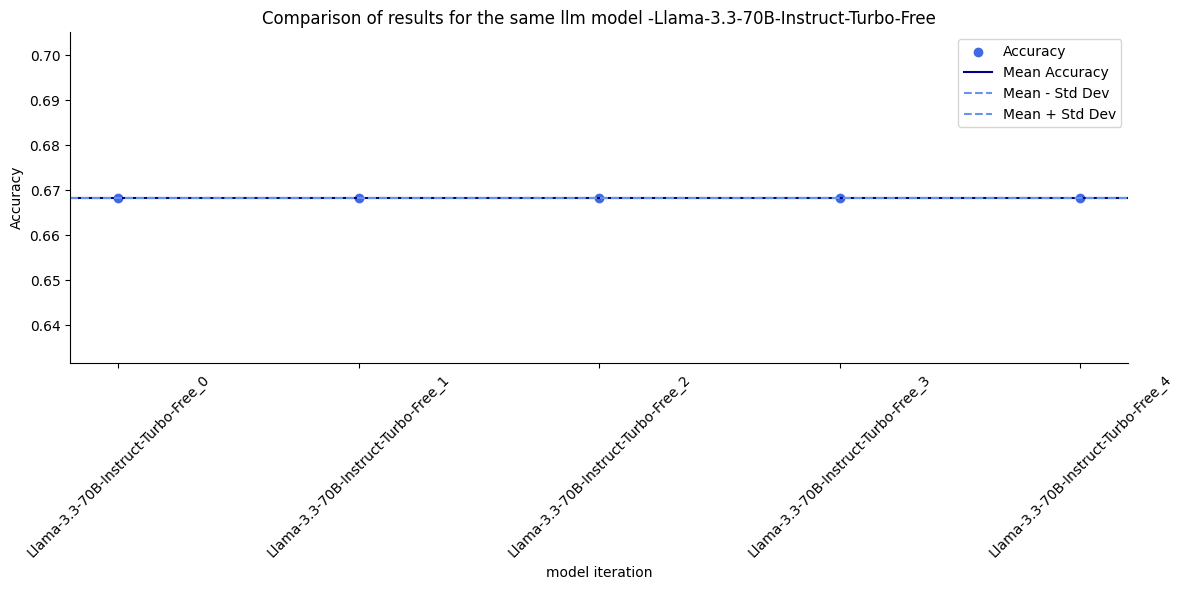

In [72]:
graph_scatter_plot(df = df_result_gpt3,
                    col_values = "Accuracy",
                    col_name_models = "Model_Iteration",
                    title_graph = "Comparison of results for the same llm model -Llama-3.3-70B-Instruct-Turbo-Free",
                    xlabel = "model iteration",
                    ylabel = "Accuracy",
                    ylim_flag=False,
                    ylim=[0.50,0.8])

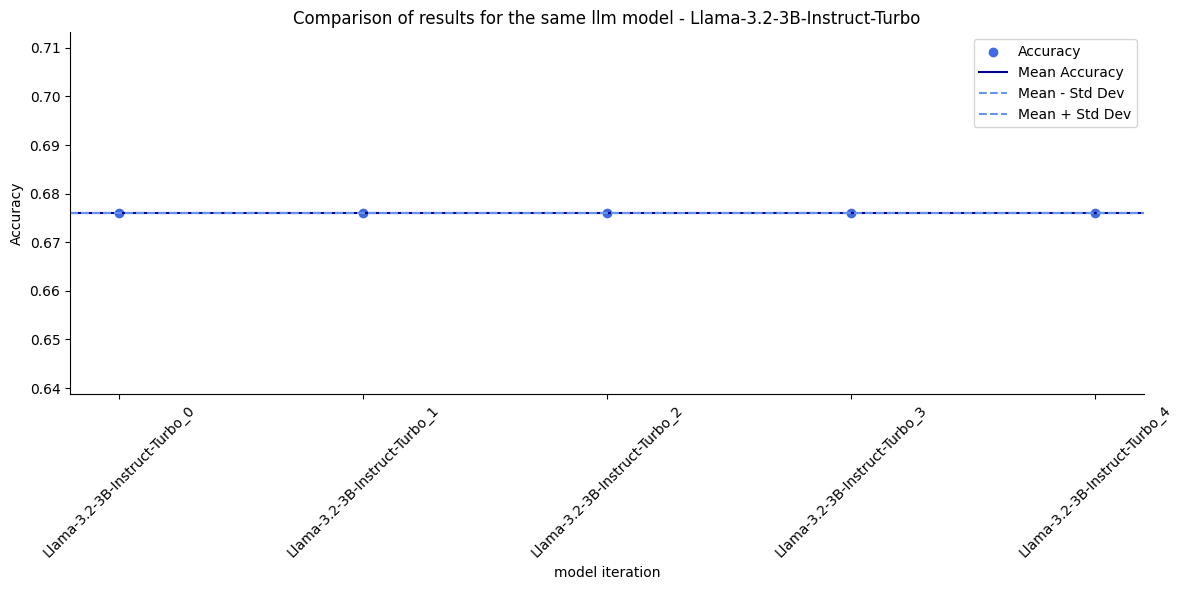

In [73]:
graph_scatter_plot(df = df_result_gpt4,
                    col_values = "Accuracy",
                    col_name_models = "Model_Iteration",
                    title_graph = "Comparison of results for the same llm model - Llama-3.2-3B-Instruct-Turbo",
                    xlabel = "model iteration",
                    ylabel = "Accuracy",
                    ylim_flag=False,
                    ylim=[0.50,0.8])

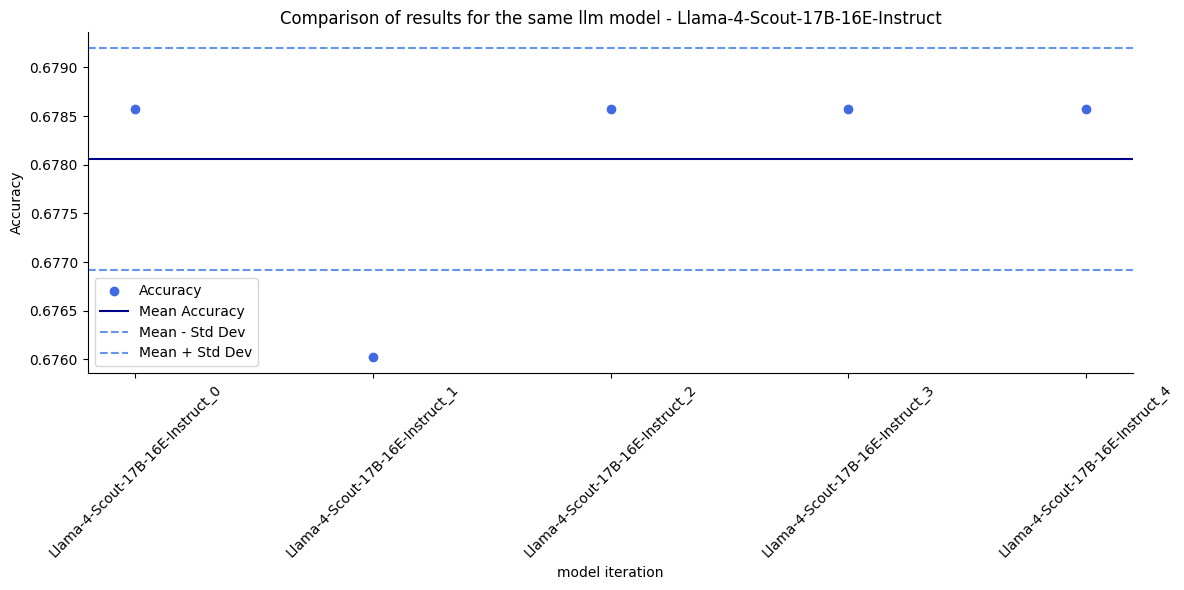

In [74]:
graph_scatter_plot(df = df_result_gpt41,
                    col_values = "Accuracy",
                    col_name_models = "Model_Iteration",
                    title_graph = "Comparison of results for the same llm model - Llama-4-Scout-17B-16E-Instruct",
                    xlabel = "model iteration",
                    ylabel = "Accuracy",
                    ylim_flag=False,
                    ylim=[0.50,0.9])

Nota-se que para modelos mais avançados a variabilidade é menor, indicando estabilização mais rápida.

In [75]:
### Grava os resultados finais
df_result_gpt3.to_excel("/data/codigos/dados/resultados/reproducao_acuracia_Llama-3.3-70B-Instruct-Turbo-Free_final_srl2_v2.xlsx", index=False)
df_result_gpt3.to_csv("/data/codigos/dados/resultados/reproducao_acuracia_Llama-3.3-70B-Instruct-Turbo-Free_final_srl2_v2.csv", encoding='utf-8', index=False)

df_result_gpt4.to_excel("/data/codigos/dados/resultados/reproducao_acuracia_Llama-3.2-3B-Instruct-Turbo_final_srl2_v2.xlsx", index=False)
df_result_gpt4.to_csv("/data/codigos/dados/resultados/reproducao_acuracia_Llama-3.2-3B-Instruct-Turbo_final_srl2_v2.csv", encoding='utf-8', index=False)

df_result_gpt41.to_excel("/data/codigos/dados/resultados/reproducao_acuracia_Llama-4-Scout-17B-16E-Instruct_final_srl2_v2.xlsx", index=False)
df_result_gpt41.to_csv("/data/codigos/dados/resultados/reproducao_acuracia_Llama-4-Scout-17B-16E-Instruct_final_srl2_v2.csv", encoding='utf-8', index=False)

### Comparativo geral

In [76]:
df_result_gpt3.head(2)

,Model_Iteration,Accuracy
0,Llama-3.3-70B-Instruct-Turbo-Free_0,0.668367
1,Llama-3.3-70B-Instruct-Turbo-Free_1,0.668367


In [77]:
df_result_gpt3["iteration"] = df_result_gpt3["Model_Iteration"].str.extract(r'_(\d+)$')[0].astype(int)
df_result_gpt3["model"] = "Llama-3.3-70B-Instruct-Turbo-Free"
df_result_gpt3

,Model_Iteration,Accuracy,iteration,model
0,Llama-3.3-70B-Instruct-Turbo-Free_0,0.668367,0,Llama-3.3-70B-Instruct-Turbo-Free
1,Llama-3.3-70B-Instruct-Turbo-Free_1,0.668367,1,Llama-3.3-70B-Instruct-Turbo-Free
2,Llama-3.3-70B-Instruct-Turbo-Free_2,0.668367,2,Llama-3.3-70B-Instruct-Turbo-Free
3,Llama-3.3-70B-Instruct-Turbo-Free_3,0.668367,3,Llama-3.3-70B-Instruct-Turbo-Free
4,Llama-3.3-70B-Instruct-Turbo-Free_4,0.668367,4,Llama-3.3-70B-Instruct-Turbo-Free


In [78]:
df_result_gpt4["iteration"] = df_result_gpt4["Model_Iteration"].str.extract(r'_(\d+)$')[0].astype(int)
df_result_gpt4["model"] = "Llama-3.2-3B-Instruct-Turbo"
df_result_gpt4

,Model_Iteration,Accuracy,iteration,model
0,Llama-3.2-3B-Instruct-Turbo_0,0.67602,0,Llama-3.2-3B-Instruct-Turbo
1,Llama-3.2-3B-Instruct-Turbo_1,0.67602,1,Llama-3.2-3B-Instruct-Turbo
2,Llama-3.2-3B-Instruct-Turbo_2,0.67602,2,Llama-3.2-3B-Instruct-Turbo
3,Llama-3.2-3B-Instruct-Turbo_3,0.67602,3,Llama-3.2-3B-Instruct-Turbo
4,Llama-3.2-3B-Instruct-Turbo_4,0.67602,4,Llama-3.2-3B-Instruct-Turbo


In [79]:
df_result_gpt41["iteration"] = df_result_gpt41["Model_Iteration"].str.extract(r'_(\d+)$')[0].astype(int)
df_result_gpt41["model"] = "Llama-4-Scout-17B-16E-Instruct"
df_result_gpt41

,Model_Iteration,Accuracy,iteration,model
0,Llama-4-Scout-17B-16E-Instruct_0,0.678571,0,Llama-4-Scout-17B-16E-Instruct
1,Llama-4-Scout-17B-16E-Instruct_1,0.676020,1,Llama-4-Scout-17B-16E-Instruct
2,Llama-4-Scout-17B-16E-Instruct_2,0.678571,2,Llama-4-Scout-17B-16E-Instruct
3,Llama-4-Scout-17B-16E-Instruct_3,0.678571,3,Llama-4-Scout-17B-16E-Instruct
4,Llama-4-Scout-17B-16E-Instruct_4,0.678571,4,Llama-4-Scout-17B-16E-Instruct


In [80]:
# concatena os dataframes
df_results = pd.concat([df_result_gpt3, df_result_gpt4, df_result_gpt41], ignore_index=True)
df_results.head(2)

,Model_Iteration,Accuracy,iteration,model
0,Llama-3.3-70B-Instruct-Turbo-Free_0,0.668367,0,Llama-3.3-70B-Instruct-Turbo-Free
1,Llama-3.3-70B-Instruct-Turbo-Free_1,0.668367,1,Llama-3.3-70B-Instruct-Turbo-Free


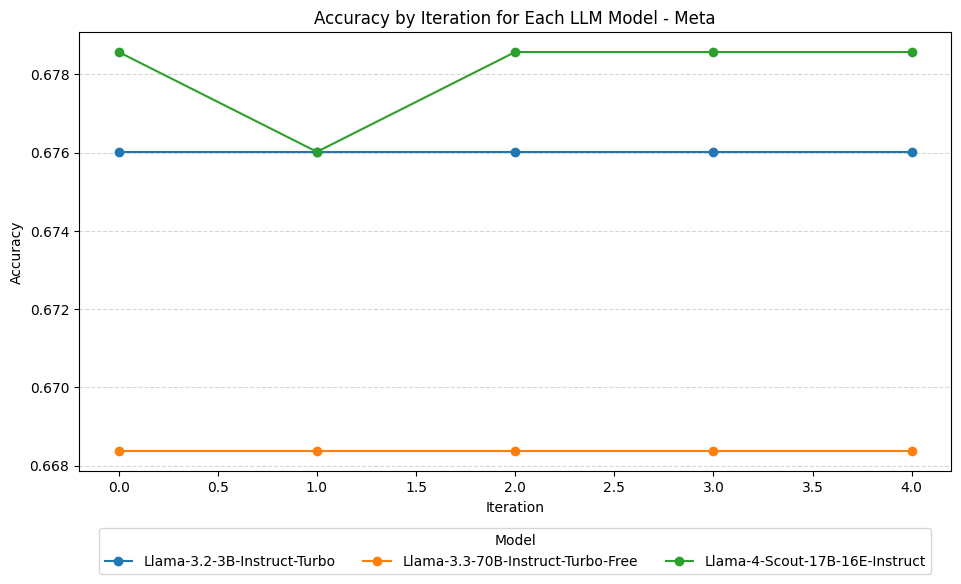

In [81]:
plt.figure(figsize=(10, 6))

for model_name, group in df_results.groupby("model"):
    plt.plot(group["iteration"], group["Accuracy"], marker='o', label=model_name)

plt.title("Accuracy by Iteration for Each LLM Model - Meta")
plt.xlabel("Iteration")
plt.ylabel("Accuracy")
plt.legend(title="Model", loc='lower center', bbox_to_anchor=(0.5, -0.25), ncol=3)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [82]:
df_results.head(2)

,Model_Iteration,Accuracy,iteration,model
0,Llama-3.3-70B-Instruct-Turbo-Free_0,0.668367,0,Llama-3.3-70B-Instruct-Turbo-Free
1,Llama-3.3-70B-Instruct-Turbo-Free_1,0.668367,1,Llama-3.3-70B-Instruct-Turbo-Free


In [83]:
summary_stats = df_results.groupby('model')['Accuracy'].agg(['mean', 'std'])
summary_stats

,mean,std
model,,
Llama-3.2-3B-Instruct-Turbo,0.676020,0.000000
Llama-3.3-70B-Instruct-Turbo-Free,0.668367,0.000000
Llama-4-Scout-17B-16E-Instruct,0.678061,0.001141


In [84]:
summary_stats["model"] = summary_stats.index
summary_stats = summary_stats.reset_index(drop=True)
summary_stats["ic_lower"] = summary_stats["mean"] - summary_stats["std"]
summary_stats["ic_upper"] = summary_stats["mean"] + summary_stats["std"]
summary_stats

,mean,std,model,ic_lower,ic_upper
0,0.676020,0.000000,Llama-3.2-3B-Instruct-Turbo,0.676020,0.676020
1,0.668367,0.000000,Llama-3.3-70B-Instruct-Turbo-Free,0.668367,0.668367
2,0.678061,0.001141,Llama-4-Scout-17B-16E-Instruct,0.676920,0.679202
